<a href="https://colab.research.google.com/github/RukeshJala/Capestone_Resale_Data_Project/blob/Projects/Capestone_Resale_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [ ]:
df1=pd.read_csv('/content/Resale Flat Prices (Based on Approval Date), 1990 - 1999.csv')
df2=pd.read_csv('/content/Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012.csv')
df3=pd.read_csv('/content/Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016.csv')
df4=pd.read_csv('/content/Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014.csv')
df5=pd.read_csv('/content/Resale flat prices based on registration date from Jan-2017 onwards.csv')

In [ ]:
df1.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
0,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977.0,9000.0
1,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977.0,6000.0
2,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977.0,8000.0
3,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977.0,6000.0
4,1990-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976.0,47200.0


In [ ]:
df1.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,93585.000000,93585.000000,93585.000000
mean,89.263407,1981.393995,125604.111834
std,26.868823,5.331824,89506.189084
min,28.000000,1967.000000,5000.000000
25%,67.000000,1978.000000,58000.000000
50%,84.000000,1983.000000,95000.000000
75%,105.000000,1985.000000,170000.000000
max,297.000000,1996.000000,615000.000000


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93586 entries, 0 to 93585
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                93586 non-null  object 
 1   town                 93585 non-null  object 
 2   flat_type            93585 non-null  object 
 3   block                93585 non-null  object 
 4   street_name          93585 non-null  object 
 5   storey_range         93585 non-null  object 
 6   floor_area_sqm       93585 non-null  float64
 7   flat_model           93585 non-null  object 
 8   lease_commence_date  93585 non-null  float64
 9   resale_price         93585 non-null  float64
dtypes: float64(3), object(7)
memory usage: 7.1+ MB


In [ ]:
df1.shape

(93586, 10)

In [ ]:
combined_df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
print(f"Shape of the combined DataFrame: {combined_df.shape}")
display(combined_df.head())

Shape of the combined DataFrame: (316093, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977.0,9000.0,NaN
1,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977.0,6000.0,NaN
2,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977.0,8000.0,NaN
3,1990-01,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977.0,6000.0,NaN
4,1990-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976.0,47200.0,NaN


In [ ]:
df1.storey_range.unique()

array(['10 TO 12', '04 TO 06', '07 TO 09', '01 TO 03', '13 TO 15',
       '19 TO 21', '16 TO 18', '25 TO 27', '22 TO 24', nan], dtype=object)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93586 entries, 0 to 93585
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                93586 non-null  object 
 1   town                 93585 non-null  object 
 2   flat_type            93585 non-null  object 
 3   block                93585 non-null  object 
 4   street_name          93585 non-null  object 
 5   storey_range         93585 non-null  object 
 6   floor_area_sqm       93585 non-null  float64
 7   flat_model           93585 non-null  object 
 8   lease_commence_date  93585 non-null  float64
 9   resale_price         93585 non-null  float64
dtypes: float64(3), object(7)
memory usage: 7.1+ MB


In [ ]:
df1.isnull().sum()

,0
month,0
town,1
flat_type,1
block,1
street_name,1
storey_range,1
floor_area_sqm,1
flat_model,1
lease_commence_date,1
resale_price,1


In [ ]:
df1.nunique()

,0
month,67
town,26
flat_type,7
block,1010
street_name,396
storey_range,9
floor_area_sqm,176
flat_model,12
lease_commence_date,30
resale_price,1914


# Task
Save the `combined_df` DataFrame to a new CSV file named 'combined_resale_data.csv' and confirm its successful creation.

## Save Combined DataFrame

### Subtask:
Save the `combined_df` DataFrame (which already contains the concatenated data from all five files) into a new CSV file named 'combined_resale_data.csv'.


**Reasoning**:
The subtask is to save the `combined_df` DataFrame to a CSV file. I will use the `to_csv()` method with `index=False` to achieve this.



In [ ]:
combined_df.to_csv('combined_resale_data.csv', index=False)
print("combined_df successfully saved to 'combined_resale_data.csv'")

combined_df successfully saved to 'combined_resale_data.csv'


## Final Task

### Subtask:
Confirm that the combined DataFrame has been successfully saved to 'combined_resale_data.csv' and inform the user.


## Summary:

### Q&A
Yes, the combined DataFrame has been successfully saved to 'combined_resale_data.csv'.

### Data Analysis Key Findings
*   The `combined_df` DataFrame was successfully saved to a CSV file named 'combined_resale_data.csv'.
*   The `index=False` parameter was used during saving, ensuring that the DataFrame's index was not included in the output CSV file.
*   The process confirmed the successful creation of the file with the message: "combined_df successfully saved to 'combined_resale_data.csv'".

### Insights or Next Steps
*   The combined resale data is now persistently stored and readily available for future analysis, eliminating the need to re-concatenate individual files.
*   This single, consolidated CSV file simplifies data access and can be easily shared or used as input for further data processing or machine learning models.


In [ ]:
combined_df.isna().sum()

,0
month,0
town,1
flat_type,1
block,1
street_name,1
storey_range,2
floor_area_sqm,3
flat_model,3
lease_commence_date,3
resale_price,3


In [ ]:
combined_df.duplicated().sum()

np.int64(965)

In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316093 entries, 0 to 316092
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                316093 non-null  object 
 1   town                 316092 non-null  object 
 2   flat_type            316092 non-null  object 
 3   block                316092 non-null  object 
 4   street_name          316092 non-null  object 
 5   storey_range         316091 non-null  object 
 6   floor_area_sqm       316090 non-null  float64
 7   flat_model           316090 non-null  object 
 8   lease_commence_date  316090 non-null  float64
 9   resale_price         316090 non-null  float64
 10  remaining_lease      90848 non-null   object 
dtypes: float64(3), object(8)
memory usage: 26.5+ MB


In [ ]:
combined_df.isnull().sum()

,0
month,0
town,1
flat_type,1
block,1
street_name,1
storey_range,2
floor_area_sqm,3
flat_model,3
lease_commence_date,3
resale_price,3


In [ ]:
combined_df.drop('remaining_lease',axis=1,inplace=True)

In [ ]:
# Re-concatenate the dataframes to include 'remaining_lease'
combined_df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Drop 'block' and 'street_name' as done previously
combined_df.drop(['block','street_name'],axis=1,inplace=True)

# Process 'month' and create 'year'
combined_df['year'] = combined_df['month'].apply(lambda x: int(str(x)[:4]))
combined_df['month'] = combined_df['month'].apply(lambda x: int(str(x)[-2:]))

# Handle object columns, including 'remaining_lease'
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Get all object columns
object_columns = combined_df.select_dtypes(include=['object']).columns

# Convert to string first to handle potential mixed types or NaN in object columns before encoding
combined_df[object_columns] = combined_df[object_columns].astype(str)

# Apply ordinal encoding
combined_df[object_columns] = ordinal_encoder.fit_transform(combined_df[object_columns])

# Drop 'town', 'flat_type', 'flat_model' as done previously
combined_df.drop(['town','flat_type','flat_model'],axis=1,inplace=True)

print("Reconstructed combined_df with 'remaining_lease' column:")
display(combined_df.head())

Reconstructed combined_df with 'remaining_lease' column:


,month,storey_range,floor_area_sqm,lease_commence_date,resale_price,remaining_lease,year
0,1,6.0,31.0,1977.0,9000.0,656.0,1990
1,1,2.0,31.0,1977.0,6000.0,656.0,1990
2,1,6.0,31.0,1977.0,8000.0,656.0,1990
3,1,4.0,31.0,1977.0,6000.0,656.0,1990
4,1,2.0,73.0,1976.0,47200.0,656.0,1990


In [ ]:
combined_df.isna().sum()

,0
month,0
town,1
flat_type,1
block,1
street_name,1
storey_range,2
floor_area_sqm,3
flat_model,3
lease_commence_date,3
resale_price,3


In [ ]:
cat_column = [col for col in combined_df.columns if combined_df[col].dtype == 'object']
cat_column = [col for col in combined_df.columns if combined_df[col].dtype == "object"]

In [ ]:
for col in cat_column:
  print(col,'-',len(combined_df[col].unique()))

month - 183
town - 28
flat_type - 9
block - 2335
street_name - 559
storey_range - 27
flat_model - 33


In [ ]:
combined_df.drop(['block','street_name'],axis=1,inplace=True)

In [ ]:
combined_df.head()

,month,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
0,1990-01,ANG MO KIO,1 ROOM,10 TO 12,31.0,IMPROVED,1977.0,9000.0
1,1990-01,ANG MO KIO,1 ROOM,04 TO 06,31.0,IMPROVED,1977.0,6000.0
2,1990-01,ANG MO KIO,1 ROOM,10 TO 12,31.0,IMPROVED,1977.0,8000.0
3,1990-01,ANG MO KIO,1 ROOM,07 TO 09,31.0,IMPROVED,1977.0,6000.0
4,1990-01,ANG MO KIO,3 ROOM,04 TO 06,73.0,NEW GENERATION,1976.0,47200.0


In [ ]:
combined_df['year'] = combined_df['month'].apply(lambda x: int(str(x)[:4]))
combined_df['month'] = combined_df['month'].apply(lambda x: int(str(x)[-2:]))

In [ ]:
combined_df.head()

,month,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,year
0,1,ANG MO KIO,1 ROOM,10 TO 12,31.0,IMPROVED,1977.0,9000.0,1990
1,1,ANG MO KIO,1 ROOM,04 TO 06,31.0,IMPROVED,1977.0,6000.0,1990
2,1,ANG MO KIO,1 ROOM,10 TO 12,31.0,IMPROVED,1977.0,8000.0,1990
3,1,ANG MO KIO,1 ROOM,07 TO 09,31.0,IMPROVED,1977.0,6000.0,1990
4,1,ANG MO KIO,3 ROOM,04 TO 06,73.0,NEW GENERATION,1976.0,47200.0,1990


In [ ]:
combined_df.year.unique()

array([1990, 1991, 1992, 1993, 1994, 1995,    1, 2000, 2001, 2002, 2015,
       2016, 2012, 2013, 2014, 2017, 2018, 2019])

In [ ]:
combined_df.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [ ]:
combined_df.isna().sum()

,0
month,0
town,1
flat_type,1
storey_range,2
floor_area_sqm,3
flat_model,3
lease_commence_date,3
resale_price,3
year,0


<Axes: xlabel='floor_area_sqm', ylabel='resale_price'>

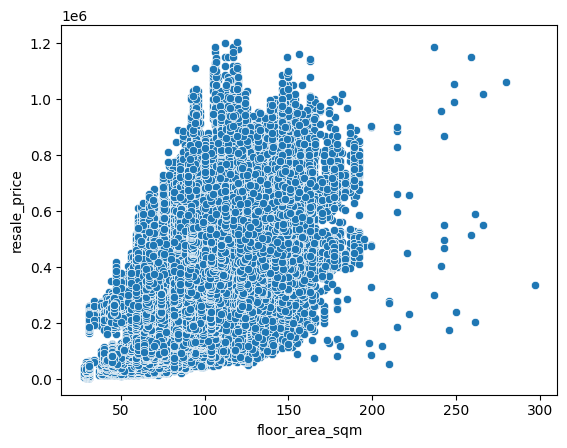

In [ ]:
sns.scatterplot(data = combined_df, x = "floor_area_sqm", y = "resale_price")

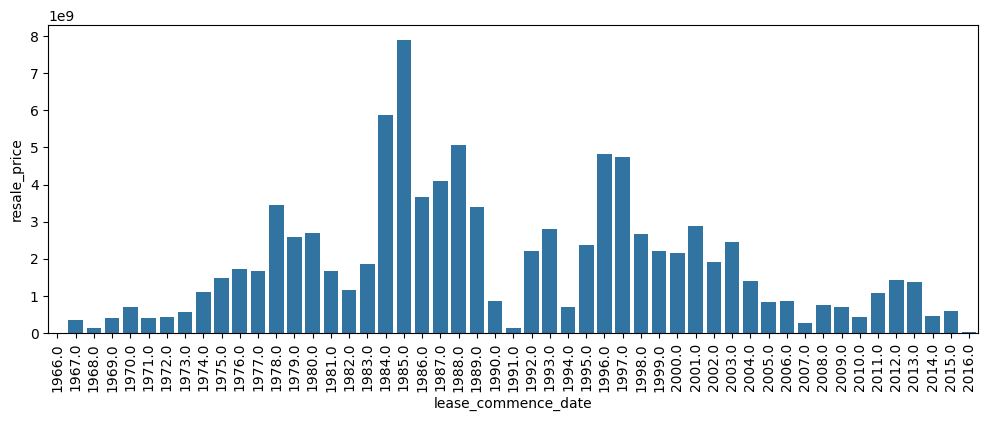

In [ ]:
plt.figure(figsize=(12,4))
a = combined_df.groupby('lease_commence_date')['resale_price'].sum()
a = pd.DataFrame(a)
sns.barplot(data=a,x=a.index,y='resale_price')
plt.xticks(rotation=90)
plt.show()

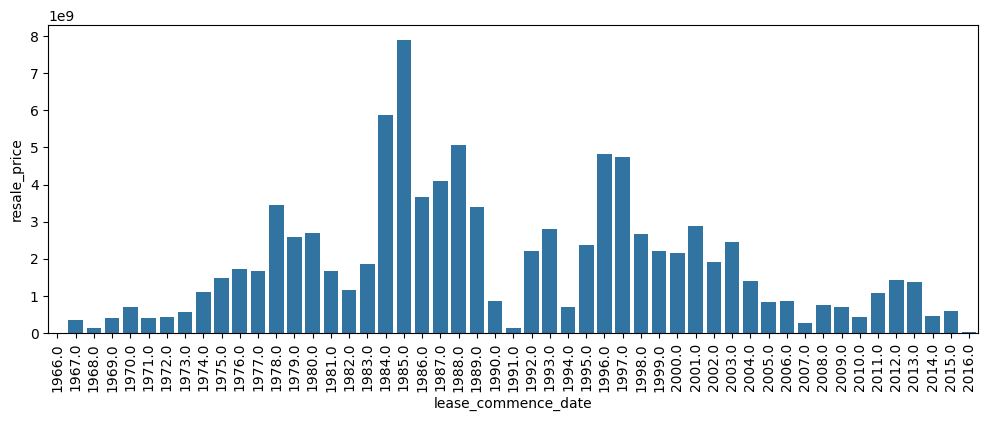

In [ ]:
plt.figure(figsize=(12,4))
a = combined_df.groupby('lease_commence_date')['resale_price'].sum()
a = pd.DataFrame(a)
sns.barplot(x=a.index, y='resale_price', data=a)
plt.xticks(rotation=90)
plt.show()

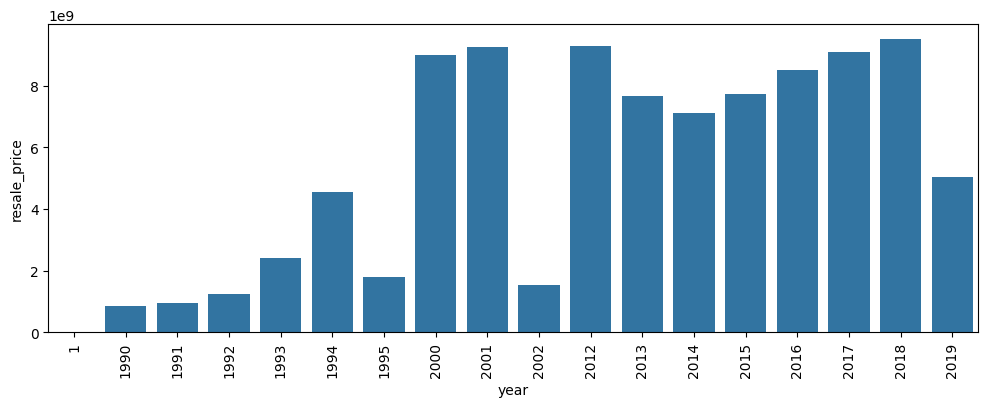

In [ ]:
plt.figure(figsize=(12,4))
a = combined_df.groupby('year')['resale_price'].sum()
a = pd.DataFrame(a)
sns.barplot(data=a,x=a.index, y='resale_price')
plt.xticks(rotation=90)
plt.show()

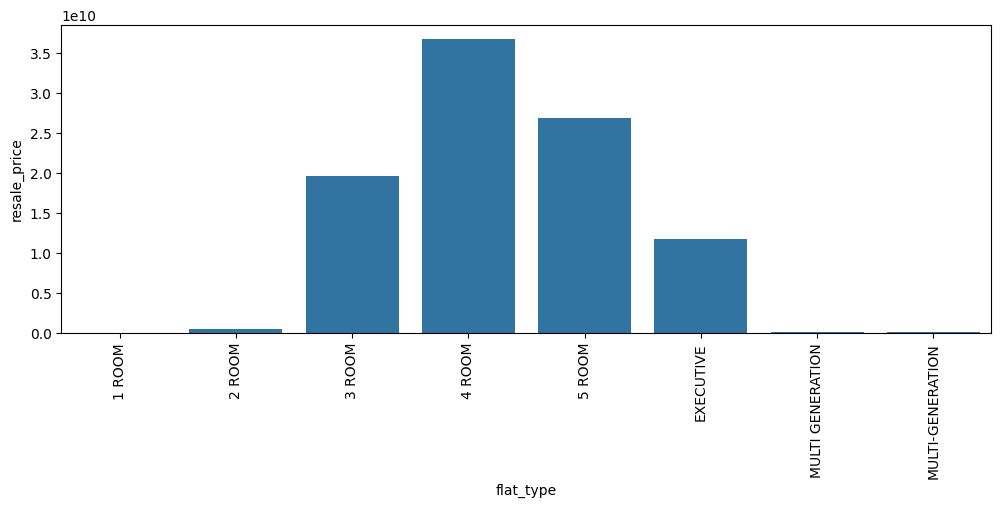

In [ ]:
plt.figure(figsize=(12,4))
a = combined_df.groupby('flat_type')['resale_price'].sum()
a = pd.DataFrame(a)
sns.barplot(data=a,x=a.index,y='resale_price')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='year'>

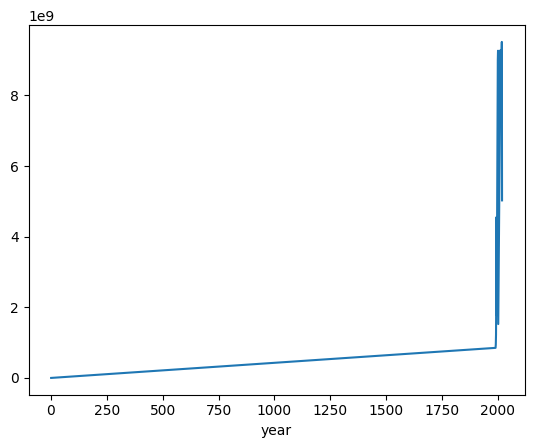

In [ ]:
combined_df.groupby('year').sum()['resale_price'].plot(kind='line')

In [ ]:
import plotly.express as px

df_agg_3d = combined_df.groupby(['year', 'flat_type'])['resale_price'].sum().reset_index()

fig = px.line_3d(df_agg_3d, x='year', y='resale_price', z='flat_type', color='flat_type',
                 title='3D Line Plot of Resale Price by Year and Flat Type')
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import OrdinalEncoder

# Re-create a version of combined_df with flat_type for plotting
# This assumes df1, df2, df3, df4, df5 are available from earlier loaded data.
df_plot = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Drop 'remaining_lease' if it exists (it did in the original combined_df)
if 'remaining_lease' in df_plot.columns:
    df_plot.drop('remaining_lease', axis=1, inplace=True)

# Drop 'block' and 'street_name' as per previous steps
df_plot.drop(['block','street_name'],axis=1,inplace=True)

# Process 'month' to 'year' and numerical 'month' as per previous steps
df_plot['year'] = df_plot['month'].apply(lambda x: int(str(x)[:4]))
df_plot['month'] = df_plot['month'].apply(lambda x: int(str(x)[-2:]))

# Ordinal encode object columns, including flat_type, as per previous steps
ordinal_encoder = OrdinalEncoder()
object_columns = df_plot.select_dtypes(include=['object']).columns
df_plot[object_columns] = df_plot[object_columns].astype(str)
df_plot[object_columns] = ordinal_encoder.fit_transform(df_plot[object_columns])

# Now plot using df_plot which contains 'flat_type'
fig = px.line(
    df_plot.groupby(['lease_commence_date', 'flat_type'])['resale_price'].sum().reset_index(),
    x='lease_commence_date', y='resale_price', color='flat_type',
    title='Line Plot of Resale Price by Lease Commence Date and Flat Type'
)
fig.show()

In [ ]:
scope_combined_df = combined_df[['floor_area_sqm','lease_commence_date','resale_price']]
scope_combined_df

,floor_area_sqm,lease_commence_date,resale_price
0,31.0,1977.0,9000.0
1,31.0,1977.0,6000.0
2,31.0,1977.0,8000.0
3,31.0,1977.0,6000.0
4,73.0,1976.0,47200.0
...,...,...,...
316088,113.0,2015.0,580000.0
316089,113.0,2015.0,584000.0
316090,112.0,2014.0,598000.0
316091,112.0,2015.0,610000.0


In [ ]:
scope_combined_df = scope_combined_df.drop_duplicates()
scope_combined_df

,floor_area_sqm,lease_commence_date,resale_price
0,31.0,1977.0,9000.0
1,31.0,1977.0,6000.0
2,31.0,1977.0,8000.0
4,73.0,1976.0,47200.0
5,67.0,1977.0,46000.0
...,...,...,...
316068,112.0,2003.0,401888.0
316086,112.0,2014.0,550888.0
316089,113.0,2015.0,584000.0
316090,112.0,2014.0,598000.0


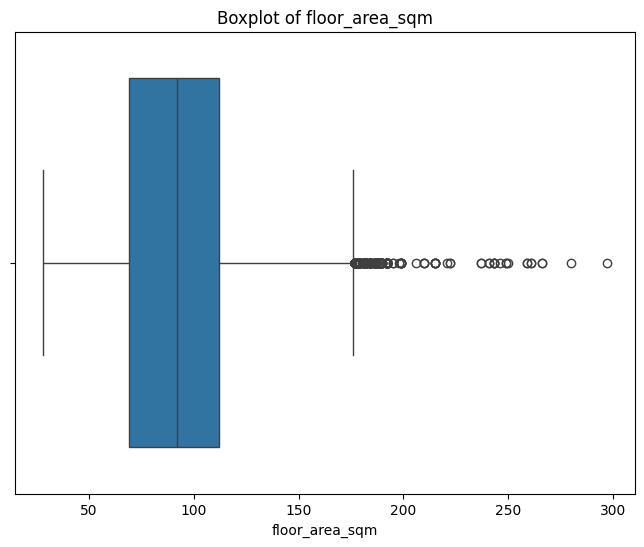

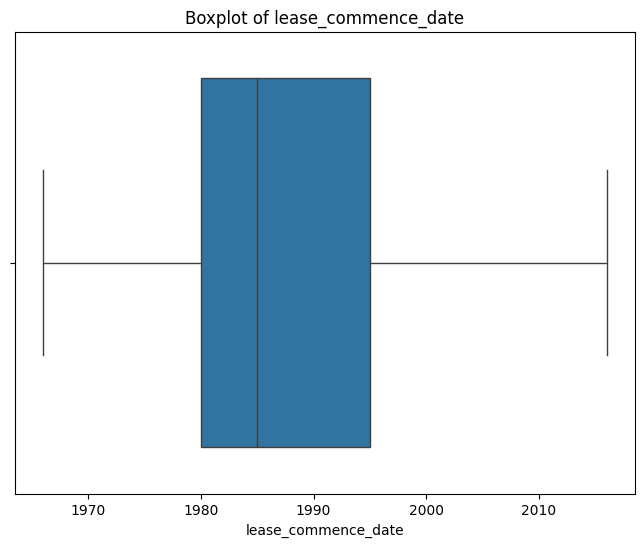

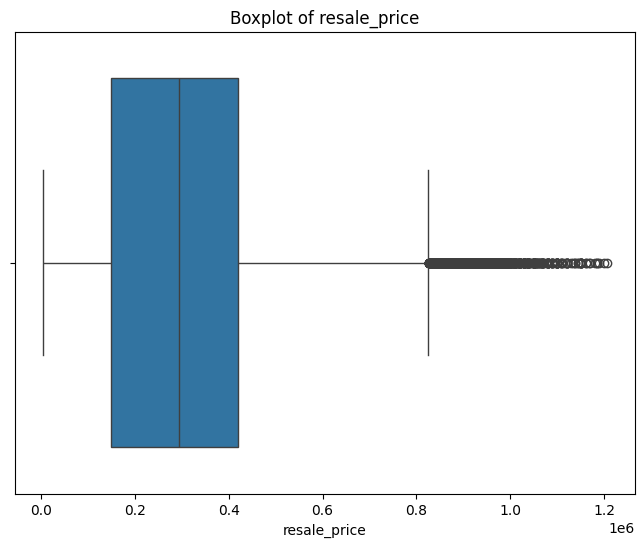

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

col = ['floor_area_sqm','lease_commence_date','resale_price']

for i in col:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=combined_df, x=i)
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(combined_df, x='floor_area_sqm', y='lease_commence_date', z='resale_price',
                    title='3D Scatter Plot of Resale Price vs. Floor Area and Lease Commence Date')
fig.show()

In [ ]:
combined_df1 = scope_combined_df

In [ ]:
combined_df1

,floor_area_sqm,lease_commence_date,resale_price
0,31.0,1977.0,9000.0
1,31.0,1977.0,6000.0
2,31.0,1977.0,8000.0
4,73.0,1976.0,47200.0
5,67.0,1977.0,46000.0
...,...,...,...
316068,112.0,2003.0,401888.0
316086,112.0,2014.0,550888.0
316089,113.0,2015.0,584000.0
316090,112.0,2014.0,598000.0


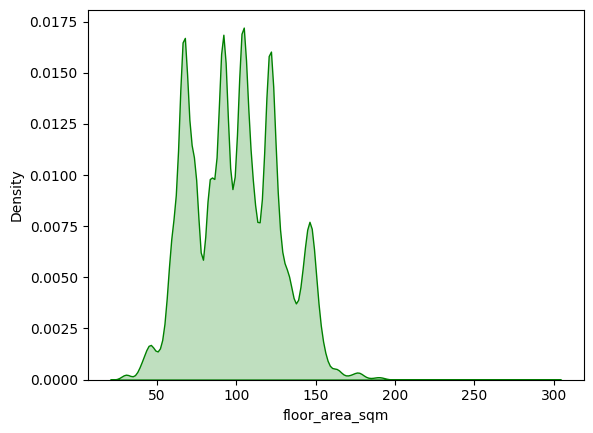

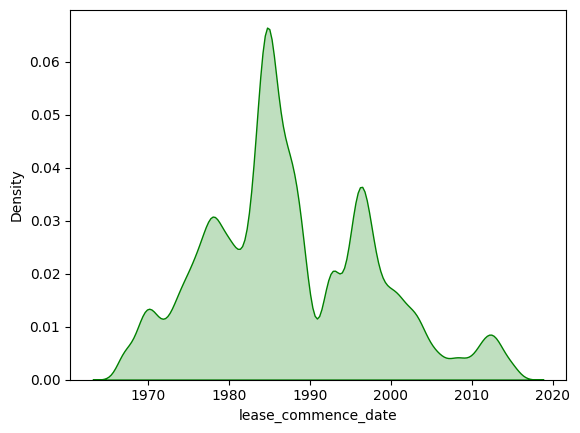

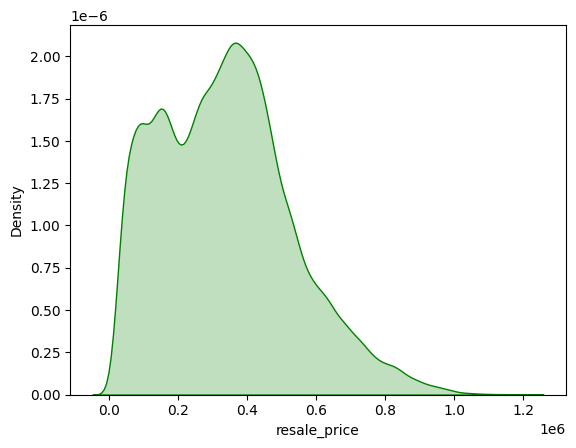

In [ ]:
for i in combined_df1.columns:
    sns.kdeplot(data=combined_df1[i],fill=True,color="g")
    plt.show()

<Axes: title={'center': 'Correlation Heatmap'}>

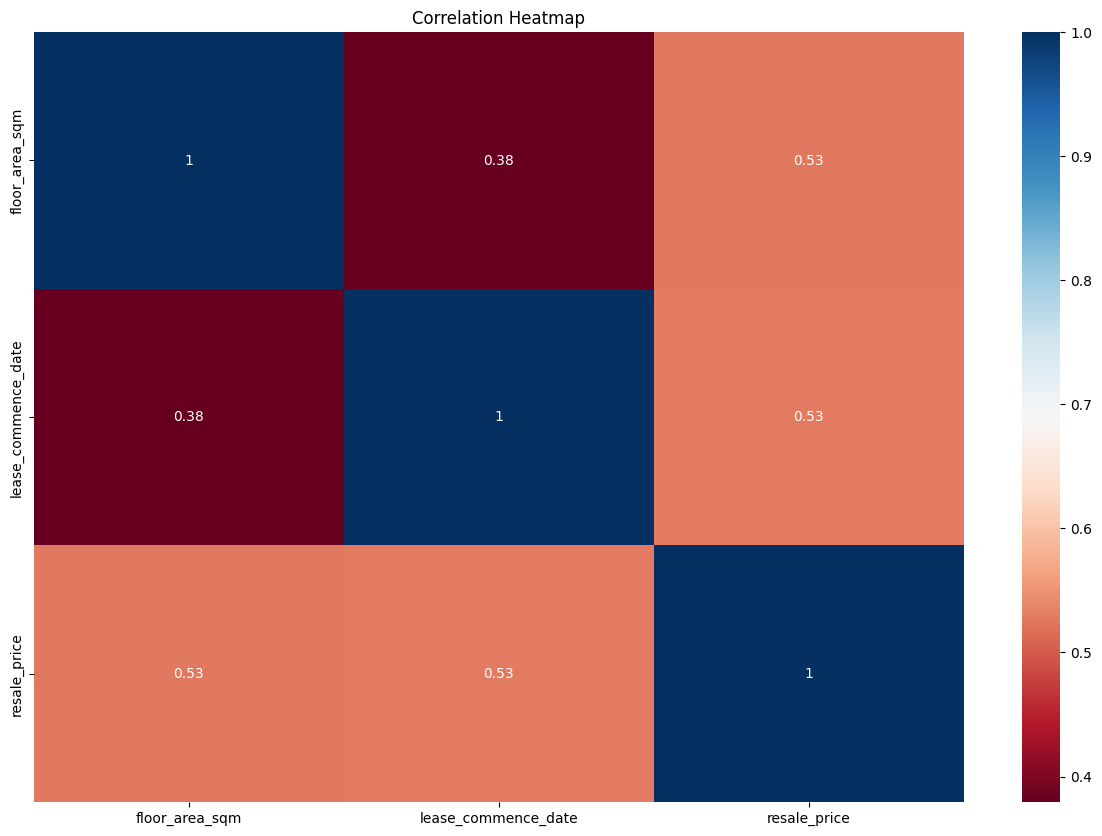

In [ ]:
import seaborn as sns

corrMatrix = combined_df1.corr()
plt.figure(figsize=(15, 10))
plt.title("Correlation Heatmap")
sns.heatmap(
    corrMatrix,
    xticklabels=corrMatrix.columns,
    yticklabels=corrMatrix.columns,
    cmap='RdBu',
    annot=True
)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

object_columns = combined_df.select_dtypes(include=['object']).columns

combined_df[object_columns] = combined_df[object_columns].astype(str)

combined_df[object_columns] = ordinal_encoder.fit_transform(combined_df[object_columns])


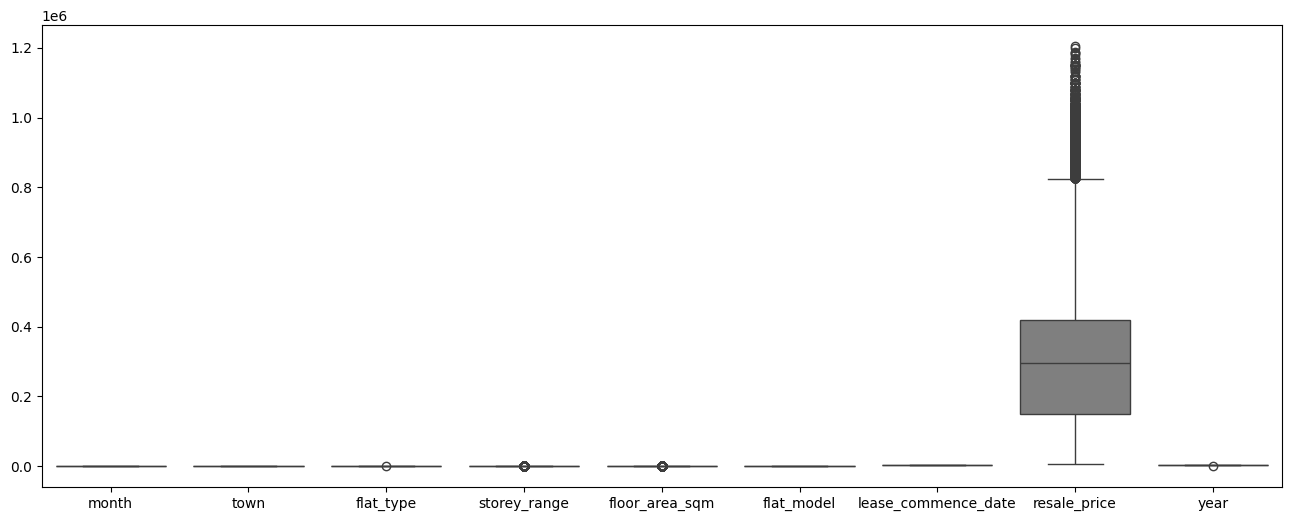

In [ ]:
plt.figure(figsize=(16,6))
sns.boxplot(data=combined_df)
plt.show()

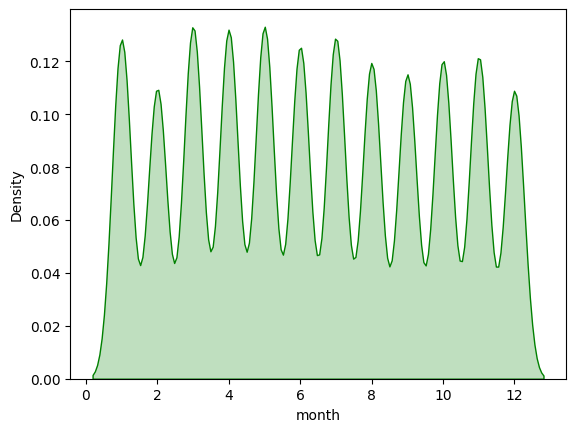

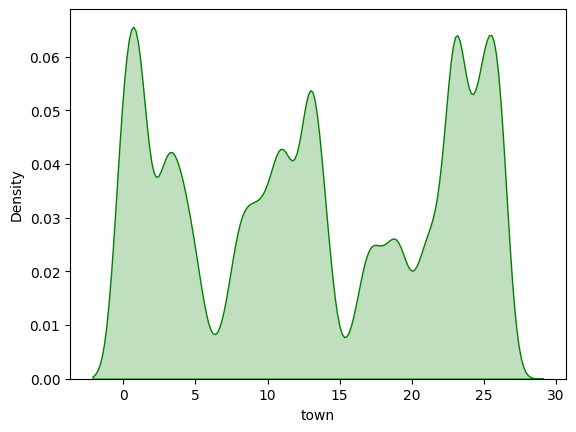

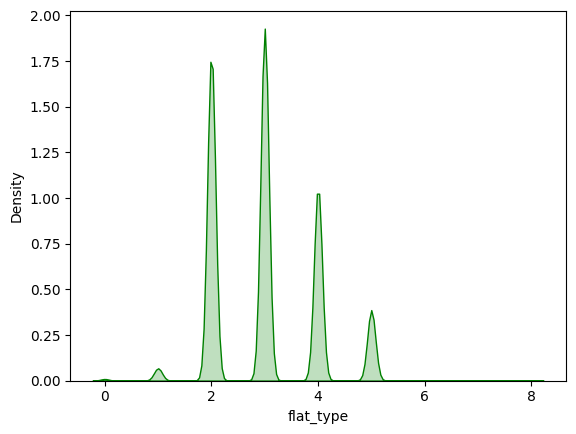

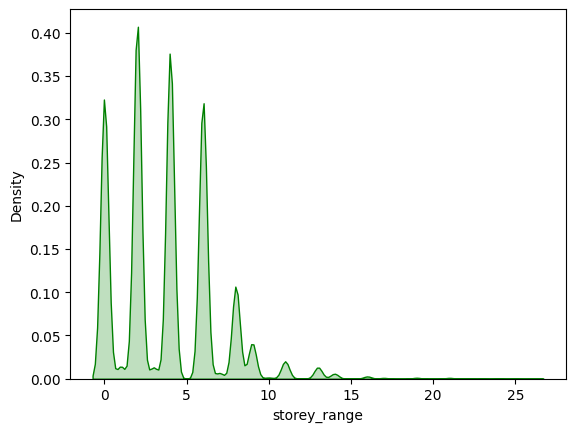

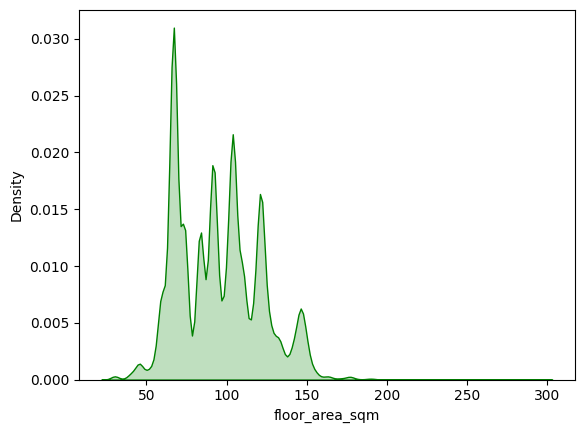

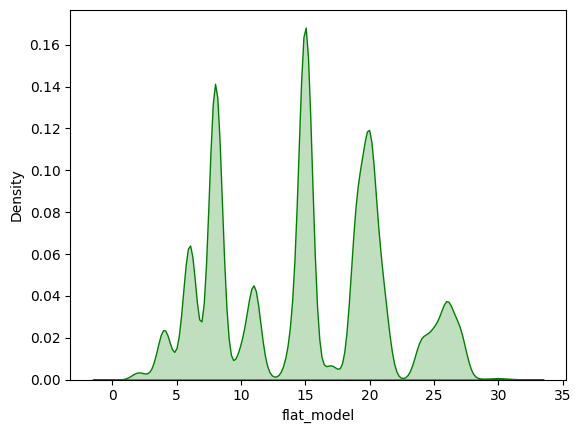

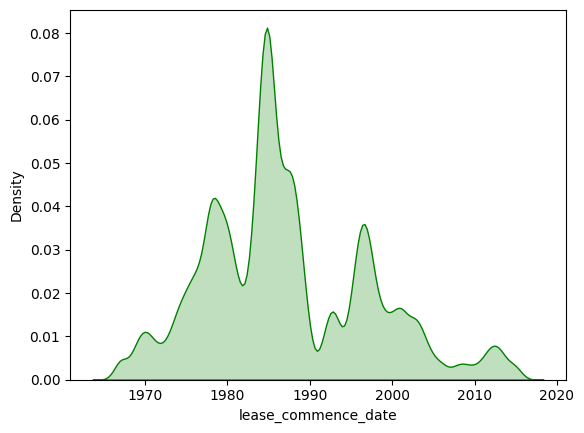

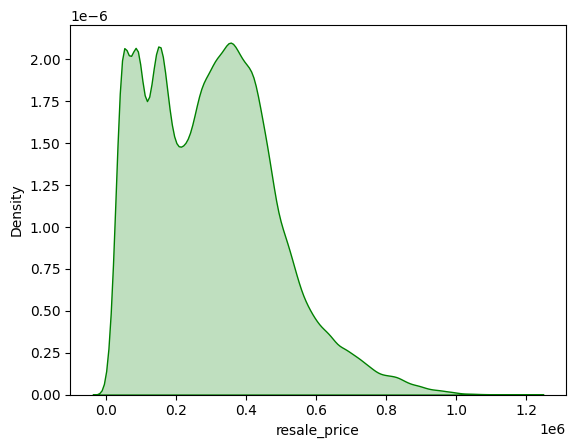

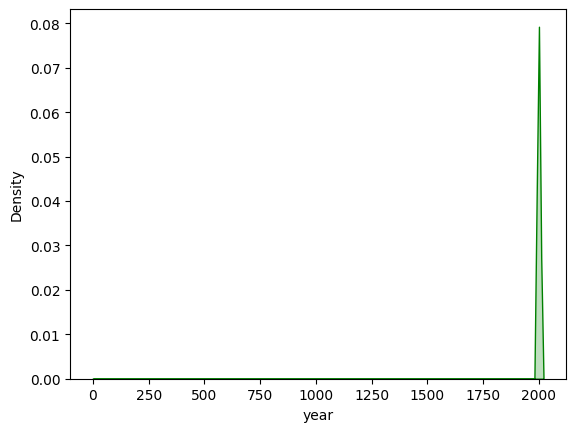

In [ ]:
for i in combined_df.columns:
    sns.kdeplot(data=combined_df[i],fill=True,color="g")
    plt.show()

<Axes: title={'center': 'Correlation Heatmap'}>

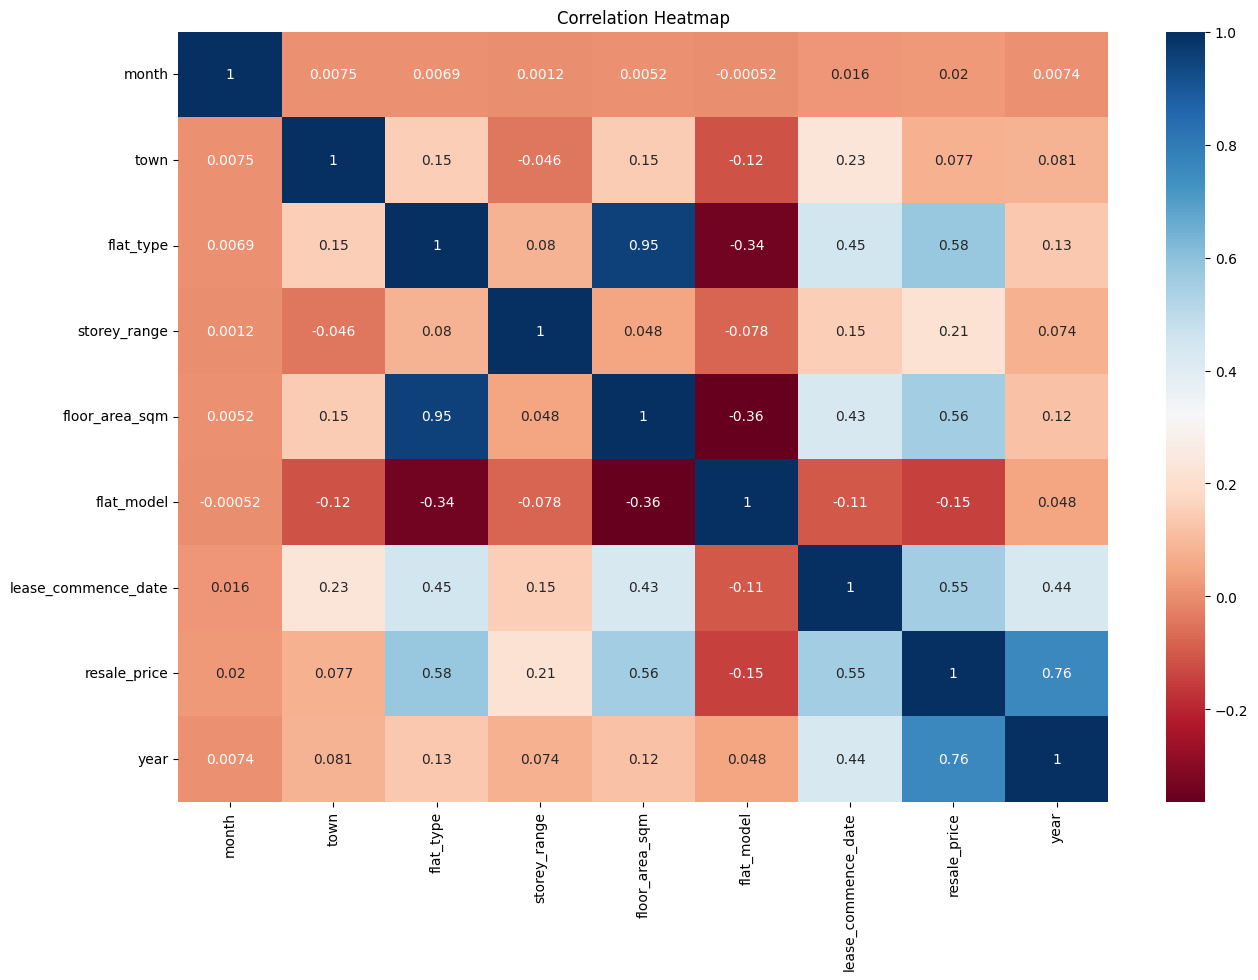

In [ ]:
import seaborn as sns

corrMatrix = combined_df.corr()
plt.figure(figsize=(15, 10))
plt.title("Correlation Heatmap")
sns.heatmap(
    corrMatrix,
    xticklabels=corrMatrix.columns,
    yticklabels=corrMatrix.columns,
    cmap='RdBu',
    annot=True
)

In [ ]:
combined_df.drop(['town','flat_type','flat_model'],axis=1,inplace=True)

In [ ]:
combined_df_cleaned = combined_df.dropna(subset=['month', 'storey_range', 'floor_area_sqm', 'lease_commence_date', 'resale_price', 'year'])
X = combined_df_cleaned.drop("resale_price",axis=1)
Y = combined_df_cleaned['resale_price']

In [ ]:
combined_df.head()

,month,storey_range,floor_area_sqm,lease_commence_date,resale_price,year
0,1,6.0,31.0,1977.0,9000.0,1990
1,1,2.0,31.0,1977.0,6000.0,1990
2,1,6.0,31.0,1977.0,8000.0,1990
3,1,4.0,31.0,1977.0,6000.0,1990
4,1,2.0,73.0,1976.0,47200.0,1990


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [ ]:
print(X_train.shape, X_test.shape)


(221265, 5) (94828, 5)


In [ ]:
from sklearn.linear_model import LinearRegression

model_LG = LinearRegression()
model_LG.fit(X_train,Y_train)

LinearRegression()

In [ ]:
predection = model_LG.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

r2_score(Y_test,predection)

0.8134840343141638

In [ ]:
pred = model_LG.predict(X_train)
r2_score(Y_train,pred)

0.8151612513245483

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model_DT = DecisionTreeRegressor()
model_DT.fit(X_train,Y_train)

DecisionTreeRegressor()

In [ ]:
Y_pred = model_DT.predict(X_test)
r2_score(Y_test,Y_pred)

0.8613640394431752

In [ ]:
Yt_pred = model_DT.predict(X_train)
r2_score(Y_train,Yt_pred)

0.9841466731679309

In [ ]:
from sklearn.metrics import mean_absolute_error as mae
mae(Y_test,Y_pred)/combined_df['resale_price'].max()

0.0333353134670871

In [ ]:
combined_df.columns

Index(['month', 'storey_range', 'floor_area_sqm', 'lease_commence_date',
       'resale_price', 'year'],
      dtype='object')

In [ ]:
import pickle
with open('DTR_model.pkl', 'wb') as file:
      pickle.dump(model_DT,file)

In [ ]:
import pickle
import numpy as np

# Load the saved Decision Tree Regressor model
with open('DTR_model.pkl', 'rb') as file:
    loaded_model_DT = pickle.load(file)

print('Model DTR_model.pkl loaded successfully.')

Model DTR_model.pkl loaded successfully.


Now that the model is loaded, we can use it to make predictions. Let's create a sample input. Based on the `combined_df` columns and its `describe()` output, the model expects the following features in this order:

1.  `month`: (e.g., 7 for July)
2.  `storey_range`: (e.g., 5.0, which is an ordinal encoded value)
3.  `floor_area_sqm`: (e.g., 122.0)
4.  `lease_commence_date`: (e.g., 1988)
5.  `year`: (e.g., 2014, the transaction year)

I'll use some example values within the range of the training data.

In [ ]:
import pandas as pd

# Define a sample input matching the features the model was trained on
# The order of features should be: month, storey_range, floor_area_sqm, lease_commence_date, year
sample_input_data = {
    'month': [7],
    'storey_range': [5.0],
    'floor_area_sqm': [122.0],
    'lease_commence_date': [1988],
    'year': [2014]
}

sample_input_df = pd.DataFrame(sample_input_data)

# Make a prediction using the loaded model
predicted_price = loaded_model_DT.predict(sample_input_df)

print(f"Predicted resale price for the sample input: ${predicted_price[0]:,.2f}")

Predicted resale price for the sample input: $511,750.00


In [ ]:
combined_df.tail()

,month,storey_range,floor_area_sqm,lease_commence_date,resale_price,year
316088,7,9.0,113.0,2015.0,580000.0,2019
316089,7,6.0,113.0,2015.0,584000.0,2019
316090,7,6.0,112.0,2014.0,598000.0,2019
316091,7,2.0,112.0,2015.0,610000.0,2019
316092,7,26.0,NaN,NaN,NaN,2019


In [ ]:
print(combined_df.floor_area_sqm.min())
print(combined_df.floor_area_sqm.max())

28.0
297.0


In [ ]:
month = 7

storey_range = 5.0
floor_area_sqm = 122.0

lease_commence_date = 1988
year = 2014

In [ ]:
# Install Streamlit and ngrok
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 107.8 MB/s eta 0:00:00


Now, let's create a Streamlit application file (`app.py`). This file will:

1.  Import necessary libraries.
2.  Load your `DTR_model.pkl`.
3.  Define a Streamlit interface to take user inputs for `month`, `storey_range`, `floor_area_sqm`, `lease_commence_date`, and `year`.
4.  Make predictions using the loaded model and display the result.

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# Load the saved Decision Tree Regressor model
with open('DTR_model.pkl', 'rb') as file:
    loaded_model_DT = pickle.load(file)

st.set_page_config(page_title="Resale Price Predictor", layout="centered")
st.title("HDB Resale Price Prediction")
st.markdown("Enter the property details to get a resale price prediction.")

# Input fields for the model features
# Ensure these match the features the model was trained on: month, storey_range, floor_area_sqm, lease_commence_date, year
month = st.slider('Month of Transaction (1-12)', 1, 12, 7)
storey_range_options = list(range(25))
storey_range_mapping = {
    '01 TO 03': 0.0,
    '04 TO 06': 1.0,
    '07 TO 09': 2.0,
    '10 TO 12': 3.0,
    '13 TO 15': 4.0,
    '16 TO 18': 5.0,
    '19 TO 21': 6.0,
    '22 TO 24': 7.0,
    '25 TO 27': 8.0,
    '28 TO 30': 9.0,
    '31 TO 33': 10.0,
    '34 TO 36': 11.0,
    '37 TO 39': 12.0,
    '40 TO 42': 13.0,
    '43 TO 45': 14.0,
    '46 TO 48': 15.0,
    '49 TO 51': 16.0
    # Add more as per your ordinal encoding, if any values higher than 25 exist
}
# For simplicity, using a generic slider. If you have the exact mapping used during training, use that.
storey_range = st.slider('Storey Range (Ordinal Encoded)', 0, 24, 5)
floor_area_sqm = st.number_input('Floor Area (sqm)', min_value=28.0, max_value=366.7, value=122.0, step=1.0)
lease_commence_date = st.slider('Lease Commence Year', 1966, 2022, 1988)
year = st.slider('Year of Transaction', 1990, 2025, 2014)

if st.button('Predict Resale Price'):
    # Create a DataFrame for prediction
    input_data = pd.DataFrame([[month, storey_range, floor_area_sqm, lease_commence_date, year]],
                               columns=['month', 'storey_range', 'floor_area_sqm', 'lease_commence_date', 'year'])

    prediction = loaded_model_DT.predict(input_data)[0]
    st.success(f"Predicted Resale Price: ${prediction:,.2f}")



Writing app.py


Now that the `app.py` file is created, we will run the Streamlit application. Since Colab notebooks run on Google's servers, the Streamlit app will be running on a private IP address. To access it from your browser, we need to expose it through a public URL using `ngrok`.

**Before running the next cell:** You will need an `ngrok` authentication token. If you don't have one, please go to [ngrok.com](https://ngrok.com/) to sign up and get your free authtoken. Add your `ngrok` token to Colab's secrets manager (the 🔑 icon on the left panel) and name it `NGROK_AUTH_TOKEN`.

In [ ]:
from pyngrok import ngrok
import subprocess
import os
from google.colab import userdata

# Get ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if not NGROK_AUTH_TOKEN:
    raise ValueError("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")

# Authenticate ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Kill any existing ngrok tunnels
ngrok.kill()

# Start Streamlit in the background
streamlit_process = subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

# Open a ngrok tunnel to the Streamlit port
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# To stop the Streamlit app and ngrok tunnel later, you'll need to manually stop the cell execution.
# Alternatively, you can run ngrok.kill() and streamlit_process.kill() in a separate cell.

Streamlit App URL: NgrokTunnel: "https://abstersive-uncaressed-kenyatta.ngrok-free.dev" -> "http://localhost:8501"


Once the previous cell executes, it will print a public URL (e.g., `https://xxxx-xx-xx-xx.ngrok-free.app`). Click on this URL to access your Streamlit application!

**To stop the Streamlit app and close the ngrok tunnel, you can interrupt the execution of the previous cell (Runtime -> Interrupt execution).**

In [ ]:
model_DT.predict(np.array([[7,122.0,1988,2018,2.0]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names



array([170000.])

In [ ]:
combined_df.describe()

,month,storey_range,floor_area_sqm,lease_commence_date,resale_price,year
count,316093.000000,316093.000000,316090.000000,316090.000000,3.160900e+05,316093.000000
mean,6.392407,3.729459,94.712932,1987.116511,3.021133e+05,2004.967481
std,3.406603,3.005669,25.954842,9.928615,1.825157e+05,10.727364
min,1.000000,0.000000,28.000000,1966.000000,5.000000e+03,1.000000
25%,3.000000,2.000000,69.000000,1980.000000,1.500000e+05,1994.000000
50%,6.000000,4.000000,92.000000,1985.000000,2.950000e+05,2001.000000
75%,9.000000,6.000000,112.000000,1995.000000,4.200000e+05,2015.000000
max,12.000000,26.000000,297.000000,2016.000000,1.205000e+06,2019.000000


In [ ]:
combined_df

,month,storey_range,floor_area_sqm,lease_commence_date,resale_price,year
0,1,6.0,31.0,1977.0,9000.0,1990
1,1,2.0,31.0,1977.0,6000.0,1990
2,1,6.0,31.0,1977.0,8000.0,1990
3,1,4.0,31.0,1977.0,6000.0,1990
4,1,2.0,73.0,1976.0,47200.0,1990
...,...,...,...,...,...,...
316088,7,9.0,113.0,2015.0,580000.0,2019
316089,7,6.0,113.0,2015.0,584000.0,2019
316090,7,6.0,112.0,2014.0,598000.0,2019
316091,7,2.0,112.0,2015.0,610000.0,2019


In [ ]:
# Re-concatenate the dataframes to include 'remaining_lease'
combined_df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Drop 'block' and 'street_name' as done previously
combined_df.drop(['block','street_name'],axis=1,inplace=True)

# Process 'month' and create 'year'
combined_df['year'] = combined_df['month'].apply(lambda x: int(str(x)[:4]))
combined_df['month'] = combined_df['month'].apply(lambda x: int(str(x)[-2:]))

# Handle object columns, including 'remaining_lease'
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Get all object columns
object_columns = combined_df.select_dtypes(include=['object']).columns

# Convert to string first to handle potential mixed types or NaN in object columns before encoding
combined_df[object_columns] = combined_df[object_columns].astype(str)

# Apply ordinal encoding
combined_df[object_columns] = ordinal_encoder.fit_transform(combined_df[object_columns])

# Drop 'town', 'flat_type', 'flat_model' as done previously
combined_df.drop(['town','flat_type','flat_model'],axis=1,inplace=True)

# Now dropping 'remaining_lease' as per your explicit instruction
combined_df.drop('remaining_lease', axis=1, inplace=True)

print("Reconstructed combined_df with 'remaining_lease' column then dropped it:")
display(combined_df.head())

Reconstructed combined_df with 'remaining_lease' column then dropped it:


,month,storey_range,floor_area_sqm,lease_commence_date,resale_price,year
0,1,6.0,31.0,1977.0,9000.0,1990
1,1,2.0,31.0,1977.0,6000.0,1990
2,1,6.0,31.0,1977.0,8000.0,1990
3,1,4.0,31.0,1977.0,6000.0,1990
4,1,2.0,73.0,1976.0,47200.0,1990
